# **THE WALK FORWARD METHOD: APPLICATION TO BITCOIN**

## **1. INTRODUCTION**

In this notebook, we illustrate the implementation of the Walk Forward method as a backtest procedure for trading strategies based on deep learning models. We will exploit hourly data of Bitcoin prices and train a classification model to predict the direction of Bitcoin's return over 4-hour intervals. 

In our previous applications of deep learning to trading strategies, we have always started by splitting the data by time into two parts, training on the first chunk of data and using the second for out-of-sample tests. This procedure is not wrong by itself but employs a very small part of the information to perform backtests. This means that we obtain estimates of the performance of our strategy from relatively few observations compared to the overall sample. Moreover, we are biasing our tests based on the ability of the models to predict out of sample only in the most recent part of the time series. For instance, the test sample may feature a booming period in security prices, and our model may perform well in those periods. However, this may obscure the fact that the model may perform terribly in downturn periods.

A simple way to overcome this--and have a general view of our trading strategies and how the underlying models perform over time--is to opt for a **Walk Forward** backtesting method. To implement a Walk Forward, we generate a sequence of out-of-sample evaluations by periodically re-training the model using a rolling, or expanding, time window.

The figure below illustrates the Walk Forward that we are going to implement below. This is a non-anchored method because we use a fixed rolling window of training data that we are going to shift sequentially so that the training set includes the test set in the previously trained model. 

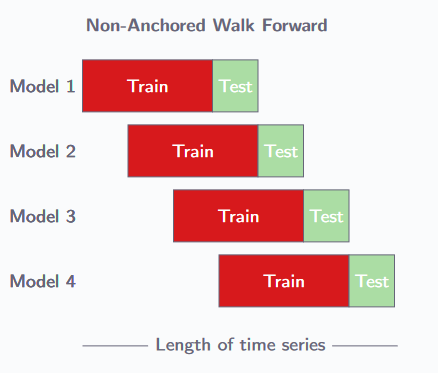

Before proceeding, we load all the required libraries and the data that we will exploit in this notebook. Among other information, the dataset covers hourly Bitcoin prices in 2013–2022. Notice that the earlier data does not include every-hour information due to the lack of transactions. For computational reasons, we will restrict the analysis to post-2020 data.

In [1]:
# %%
import numpy as np
import pandas as pd
import tensorflow as tf

# %%
# ====================================================
name = "Kraken_BTCUSD_60_3Q2022"
df = pd.read_csv(name + ".csv")

df["unix"] = pd.to_numeric(df["unix"])
df["date"] = pd.to_datetime(df["unix"], unit="s")

2025-05-26 12:39:11.666012: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-26 12:39:11.716667: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-26 12:39:13.064196: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
df = df[["date", "close", "volume", "trades"]]

In [3]:
df.head()

,date,close,volume,trades
0,2013-10-06 21:00:00,122.00,0.1000,1
1,2013-10-07 20:00:00,123.61,0.1000,1
2,2013-10-08 02:00:00,123.90,1.9916,2
3,2013-10-08 05:00:00,124.18,2.0000,2
4,2013-10-09 09:00:00,123.84,2.8230,3


In [4]:
df.tail()

,date,close,volume,trades
67886,2022-09-30 19:00:00,19497.2,290.023381,1947
67887,2022-09-30 20:00:00,19420.4,759.074836,1648
67888,2022-09-30 21:00:00,19360.4,564.894247,1245
67889,2022-09-30 22:00:00,19387.1,90.626135,1978
67890,2022-09-30 23:00:00,19425.2,57.986112,2466


In [5]:
df["Ret"] = df["close"].pct_change()

In [6]:
df["year"] = df["date"].dt.year

In [7]:
df.tail()

,date,close,volume,trades,Ret,year
67886,2022-09-30 19:00:00,19497.2,290.023381,1947,-0.008941,2022
67887,2022-09-30 20:00:00,19420.4,759.074836,1648,-0.003939,2022
67888,2022-09-30 21:00:00,19360.4,564.894247,1245,-0.003090,2022
67889,2022-09-30 22:00:00,19387.1,90.626135,1978,0.001379,2022
67890,2022-09-30 23:00:00,19425.2,57.986112,2466,0.001965,2022


In [8]:
del df["close"]
df = df.loc[(df["year"] >= 2020)]
df.head()

,date,volume,trades,Ret,year
43802,2020-01-01 00:00:00,70.761775,267,-0.001758,2020
43803,2020-01-01 01:00:00,224.921206,528,0.005408,2020
43804,2020-01-01 02:00:00,138.910528,336,0.003906,2020
43805,2020-01-01 03:00:00,97.687456,240,-0.002908,2020
43806,2020-01-01 04:00:00,25.305555,131,-0.001236,2020


In [9]:
df["Ret"] = df["Ret"].fillna(0)
df["volume"] = df["volume"].fillna(0)
df["trades"] = df["trades"].fillna(0)
df.head()

,date,volume,trades,Ret,year
43802,2020-01-01 00:00:00,70.761775,267,-0.001758,2020
43803,2020-01-01 01:00:00,224.921206,528,0.005408,2020
43804,2020-01-01 02:00:00,138.910528,336,0.003906,2020
43805,2020-01-01 03:00:00,97.687456,240,-0.002908,2020
43806,2020-01-01 04:00:00,25.305555,131,-0.001236,2020


In [10]:
df

,date,volume,trades,Ret,year
43802,2020-01-01 00:00:00,70.761775,267,-0.001758,2020
43803,2020-01-01 01:00:00,224.921206,528,0.005408,2020
43804,2020-01-01 02:00:00,138.910528,336,0.003906,2020
43805,2020-01-01 03:00:00,97.687456,240,-0.002908,2020
43806,2020-01-01 04:00:00,25.305555,131,-0.001236,2020
...,...,...,...,...,...
67886,2022-09-30 19:00:00,290.023381,1947,-0.008941,2022
67887,2022-09-30 20:00:00,759.074836,1648,-0.003939,2022
67888,2022-09-30 21:00:00,564.894247,1245,-0.003090,2022
67889,2022-09-30 22:00:00,90.626135,1978,0.001379,2022


## **2. SETTING UP AND TRAINING THE FORECASTING MODEL**

To illustrate the workings of Walk Forward, we will resort to a "plain vanilla" MLP architecture where the label to predict is the direction of the cumulative Bitcoin return over the next 4-hour interval. That is, we set up a binary classification problem where the positive class is a positive return and the negative class is a zero or negative return. The input features are the lags of the hourly Bitcoin returns over the previous 15 days, meaning that we have 24x15=360 features. Our final time series consists of more than 23,000 observations.

In [11]:
df = df.reindex(
    columns=[
        "date",
        "Ret",
        "volume",
        "trades",
        "year",
        "month",
        "day",
        "week",
        "weekday",
        "hour",
    ]
)
df = df[["date", "Ret"]]

n_lags = 24 * 15

for i in range(1, n_lags + 1):
    name = "Ret_" + str(i)
    df[name] = df["Ret"].shift(i)

df["Ret4_i"] = df["Ret"].rolling(4).apply(lambda x: 100 * (np.prod(1 + x / 100) - 1))
df["Ret4"] = df["Ret4_i"].shift(-4)
df["Output"] = df["Ret4"] > 0
df["Output"] = df["Output"].astype(int)
del df["Ret4"]
del df["Ret4_i"]

df = df.dropna()

/tmp/ipykernel_44/604952926.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[name] = df["Ret"].shift(i)
/tmp/ipykernel_44/604952926.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[name] = df["Ret"].shift(i)
/tmp/ipykernel_44/604952926.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


In [12]:
X, y = df.iloc[:, 2:-1], df.iloc[:, -1]
print(X.shape, y.shape)

(23729, 360) (23729,)


The MLP's architecture includes three fully connected hidden layers with, respectively, 85, 55, and 30 hidden units. Each hidden layer features a ReLU activation function and a sigmoid function in the output layer. As regularization tools, we introduce Dropout after all the hidden layers and an early stopping criterion.

In [13]:
hp_units = 85
hp_units_2 = 55
hp_units_3 = 30
n_dropout = 0.2
act_fun = "relu"

Below, we implement the full Walk Forward loop. The size of the training window is 5,000 observations, and the test window has 1,000 observations. Starting at the beginning of our dataset, we are going to train the model using 5,000 observations and test its out-of-sample performance for the following 1,000 observations. After that, we shift the training window 1,000 observations and repeat the process until we reach the end of the full sample. We store in a pandas data frame the prediction results for each test observation.<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

In [14]:
n_train = 5000
n_test = 1000

time_backtest = []
time_backtest = np.array(time_backtest)
time_backtest = time_backtest.astype("datetime64", copy=False)

pred_backtest = []
ret_backtest = []

for i in range(0, len(y) - n_train, n_test):
    X_train, X_test = X[i : i + (n_train)], X[i + n_train : i + n_train + n_test]
    y_train, y_test = y[i : i + (n_train)], y[i + n_train : i + n_train + n_test]
    test_time = df.iloc[i + (n_train) : i + n_train + n_test, 0:1].values
    Ret_vector = df.iloc[i + (n_train) : i + n_train + n_test, 1:2].values
    print(
        "ite ",
        i / n_test,
        " -- start test:",
        test_time[0],
        " -- end test",
        test_time[-1],
        " ------- ",
        X_train.shape,
        y_train.shape,
        X_test.shape,
        y_test.shape,
        test_time.shape,
        Ret_vector.shape,
    )

    tf.keras.backend.clear_session()
    tf.random.set_seed(1234)

    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.Dense(units=hp_units, activation=act_fun))
    model.add(tf.keras.layers.Dropout(n_dropout))
    model.add(tf.keras.layers.Dense(units=hp_units_2, activation=act_fun))
    model.add(tf.keras.layers.Dropout(n_dropout))
    model.add(tf.keras.layers.Dense(units=hp_units_3, activation=act_fun))
    model.add(tf.keras.layers.Dropout(n_dropout))
    model.add(tf.keras.layers.Dense(units=1, activation="sigmoid"))

    hp_lr = 1e-5

    adam = tf.keras.optimizers.Adam(learning_rate=hp_lr)
    model.compile(optimizer=adam, loss="binary_crossentropy", metrics=["accuracy"])

    es = tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        verbose=0,
        patience=20,
        restore_best_weights=True,
    )
    class_weight = {0: (np.mean(y_train) / 0.5), 1: 1}
    history = model.fit(
        X_train,
        y_train,
        validation_split=0.15,
        epochs=500,
        batch_size=32,
        verbose=0,
        callbacks=[es],
        class_weight=class_weight,
    )

    y_prob = model.predict(X_test, verbose=0)
    y_pred = np.where(y_prob > 0.50, 1, 0)

    time_backtest = np.append(time_backtest, test_time.flatten())
    pred_backtest = np.append(pred_backtest, y_pred.flatten())
    ret_backtest = np.append(ret_backtest, Ret_vector.flatten())

df_predictions = pd.DataFrame(
    {"Date": time_backtest, "Pred": pred_backtest, "Ret": ret_backtest}
)

ite  0.0  -- start test: ['2020-08-11T08:00:00.000000000']  -- end test ['2020-09-21T23:00:00.000000000']  -------  (5000, 360) (5000,) (1000, 360) (1000,) (1000, 1) (1000, 1)
ite  1.0  -- start test: ['2020-09-22T00:00:00.000000000']  -- end test ['2020-11-02T16:00:00.000000000']  -------  (5000, 360) (5000,) (1000, 360) (1000,) (1000, 1) (1000, 1)
ite  2.0  -- start test: ['2020-11-02T17:00:00.000000000']  -- end test ['2020-12-14T08:00:00.000000000']  -------  (5000, 360) (5000,) (1000, 360) (1000,) (1000, 1) (1000, 1)
ite  3.0  -- start test: ['2020-12-14T09:00:00.000000000']  -- end test ['2021-01-25T00:00:00.000000000']  -------  (5000, 360) (5000,) (1000, 360) (1000,) (1000, 1) (1000, 1)
ite  4.0  -- start test: ['2021-01-25T01:00:00.000000000']  -- end test ['2021-03-07T17:00:00.000000000']  -------  (5000, 360) (5000,) (1000, 360) (1000,) (1000, 1) (1000, 1)
ite  5.0  -- start test: ['2021-03-07T18:00:00.000000000']  -- end test ['2021-04-18T09:00:00.000000000']  -------  (500

In [15]:
df_predictions.Date = pd.to_datetime(df_predictions.Date, format="%YYYY-%mm-%dd")
df_res = df_predictions
df_res.tail()

,Date,Pred,Ret
18724,2022-09-30 19:00:00,1.0,-0.008941
18725,2022-09-30 20:00:00,0.0,-0.003939
18726,2022-09-30 21:00:00,1.0,-0.003090
18727,2022-09-30 22:00:00,0.0,0.001379
18728,2022-09-30 23:00:00,0.0,0.001965


## **3. RESULTS**

Using the predictions of the trained models over all the test samples, we can now perform our backtest and obtain estimates of the returns of the underlying trading strategy. We will compare the cumulative returns of three different strategies:

1. A buy-and-hold strategy that is long on Bitcoin as of the beginning of the sample period. 
2. A Long-Short strategy that arises from the predictions of the MLP: The position is long one unit when the predicted probability of a positive return over 4 hours is greater than 0.5 and the position is short one unit otherwise.
3. A Long-only strategy that arises from the predictions of the MLP. The position is long one unit when the predicted probability of a positive return over 4 hours is greater than 0.5 and the position is zero otherwise.

Below, we report the cumulative returns and display the evolution of returns of these three strategies. Note that while we have fixed some seeds for the random number generators, there is some additional randomness involved and the results may vary each time you run the code.

In [16]:
df_res["Positions"] = np.where(df_res["Pred"] > 0.5, 1, -1)
df_res["Positions_shift"] = df_res["Positions"].shift(1)
df_res["Strat_ret"] = df_res["Positions"].shift(1) * df_res["Ret"]
df_res["Positions_L"] = df_res["Positions"].shift(1)
df_res["Positions_L"][df_res["Positions_L"] == -1] = 0
df_res["Strat_ret_L"] = df_res["Positions_L"] * df_res["Ret"]
df_res["CumRet"] = df_res["Strat_ret"].expanding().apply(lambda x: np.prod(1 + x) - 1)
df_res["CumRet_L"] = (
    df_res["Strat_ret_L"].expanding().apply(lambda x: np.prod(1 + x) - 1)
)
df_res["bhRet"] = df_res["Ret"].expanding().apply(lambda x: np.prod(1 + x) - 1)

Final_Return_L = np.prod(1 + df_res["Strat_ret_L"]) - 1
Final_Return = np.prod(1 + df_res["Strat_ret"]) - 1
Buy_Return = np.prod(1 + df_res["Ret"]) - 1

print("Strat Return Long Only =", Final_Return_L * 100, "%")
print("Strat Return =", Final_Return * 100, "%")
print("Buy and Hold Return =", Buy_Return * 100, "%")

/tmp/ipykernel_44/529454916.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res["Positions_L"][df_res["Positions_L"] == -1] = 0


Strat Return Long Only = 143.26678717315295 %
Strat Return = 190.02851215121103 %
Buy and Hold Return = 65.15499328334393 %


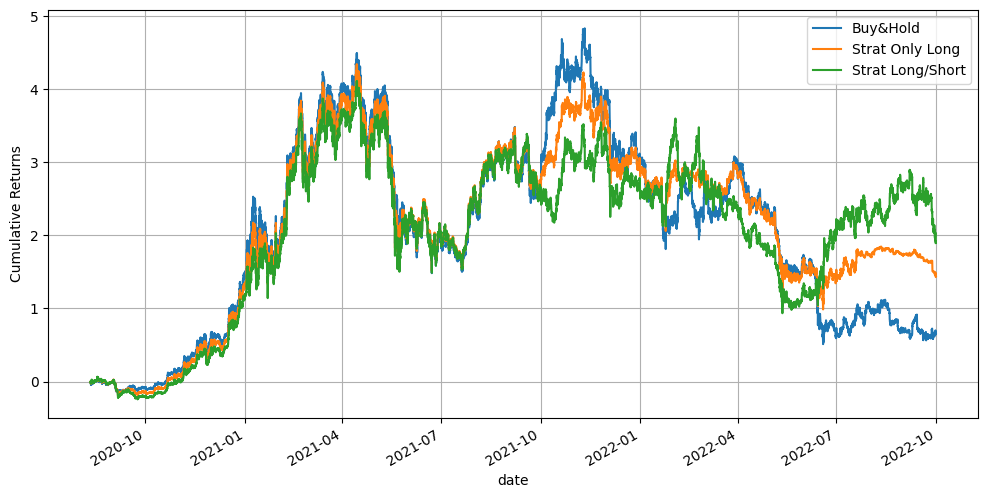

,Date,Pred,Ret,Positions,Positions_shift,Strat_ret,Positions_L,Strat_ret_L,CumRet,CumRet_L,bhRet,trade_bin
count,18729,18729.000000,18729.000000,18729.000000,18728.000000,18728.000000,18728.000000,18728.000000,18728.000000,18728.000000,18729.000000,18728.000000
mean,2021-09-05 16:28:15.338779648,0.774895,0.000060,0.549789,0.549872,0.000090,0.774936,0.000075,2.054493,2.120305,2.053200,0.184910
min,2020-08-11 08:00:00,0.000000,-0.121059,-1.000000,-1.000000,-0.121059,0.000000,-0.121059,-0.241592,-0.185183,-0.154755,0.000000
25%,2021-02-22 12:00:00,1.000000,-0.003351,1.000000,1.000000,-0.003339,1.000000,-0.002189,1.508844,1.510123,0.821464,0.000000
50%,2021-09-05 19:00:00,1.000000,0.000090,1.000000,1.000000,0.000128,1.000000,0.000000,2.332326,2.215895,2.209577,0.000000
75%,2022-03-19 21:00:00,1.000000,0.003556,1.000000,1.000000,0.003580,1.000000,0.002448,2.829753,2.969356,3.033303,0.000000
max,2022-09-30 23:00:00,1.000000,0.124064,1.000000,1.000000,0.124064,1.000000,0.124064,4.110985,4.340209,4.832441,1.000000
std,NaN,0.417663,0.008154,0.835326,0.835271,0.008154,0.417636,0.007445,1.091337,1.155828,1.292641,0.388235


In [17]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 6))
ax = plt.gca()
df_res.plot(x="Date", y="bhRet", label="Buy&Hold", ax=ax)
df_res.plot(x="Date", y="CumRet_L", label="Strat Only Long", ax=ax)
df_res.plot(x="Date", y="CumRet", label="Strat Long/Short", ax=ax)
plt.xlabel("date")
plt.ylabel("Cumulative Returns")
plt.grid()
plt.show()

df_res["trade_bin"] = df_res["Positions"].diff().abs()
df_res["trade_bin"] = df_res["trade_bin"] / 2
df_res.describe()

## **4. CONCLUSION**

In this notebook, we have outlined and implemented the Walk Forward method to increase the robustness of our backtests for strategies based on Deep Learning methods.

In Lesson 3, we will describe a more advanced method to robustify our backtests: the Combinatorial Purged Cross-Validation. 

See you there!